# 06 · Feature signal within the thin-file segment (Issue #7)

```
03_clean_missing_outliers
04_feature_engineering  ──►  data/processed/features_train.parquet
        ▼
06_thin_file_signal      ◄── this notebook
```

**Why this notebook exists.** Notebook 04 ranks every numeric feature by univariate ROC-AUC
across all ~1M applicants. Because ~70% of applicants have credit-bureau records, that ranking is
dominated by `cb_*` and `pay_*` features. For the ~300k thin-file applicants those columns are
`0` or `NaN` by construction, so the existing ranking does not tell us what predicts default for
the segment this project is built around.

**Two outputs:**

1. Which features are *dead* for thin-file applicants (constant or entirely missing), so they are
   not carried into October's models as noise.
2. A univariate AUC ranking computed **within the thin-file segment only**, compared side by side
   against the established segment.

Fitted on training weeks (`WEEK_NUM < 80`) only — the validation and test weeks are never touched.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"

# Same cutoff as notebooks 04/05: weeks 80-91 are out-of-time validation,
# so anything learned from data is fitted on weeks < 80 only.
VALID_START_WEEK = 80

pd.set_option("display.width", 120)

## 1. Load and split by segment

In [2]:
train = pd.read_parquet(PROCESSED / "features_train.parquet")
fit = train[train["WEEK_NUM"] < VALID_START_WEEK]

thin = fit[fit["thin_file"] == 1]
est = fit[fit["thin_file"] == 0]

print(f"fit weeks      {fit['WEEK_NUM'].min()}-{fit['WEEK_NUM'].max()}  ({len(fit):,} applicants)")
print(f"thin-file      {len(thin):>9,}  ({len(thin)/len(fit):.1%})  default rate {thin['target'].mean():.3f}")
print(f"established    {len(est):>9,}  ({len(est)/len(fit):.1%})  default rate {est['target'].mean():.3f}")

fit weeks      0-79  (869,559 applicants)
thin-file        260,820  (30.0%)  default rate 0.265
established      608,739  (70.0%)  default rate 0.164


## 2. Which features are dead for thin-file applicants?

`thin_file` is excluded from the feature list here. It is a segment flag, not a predictor — it
correlates with `target` by definition, so including it would inflate the ranking.

In [3]:
drop = ["case_id", "target", "WEEK_NUM", "thin_file"]
feature_cols = fit.select_dtypes("number").drop(columns=drop, errors="ignore").columns

coverage = pd.DataFrame({
    "null_share_thin": thin[feature_cols].isna().mean(),
    "nunique_thin": thin[feature_cols].nunique(dropna=True),
    "null_share_est": est[feature_cols].isna().mean(),
    "nunique_est": est[feature_cols].nunique(dropna=True),
}).round(3)

# "Dead" = no variation to learn from within the thin-file segment.
coverage["dead_for_thin"] = coverage["nunique_thin"] <= 1

dead = coverage[coverage["dead_for_thin"]].index.tolist()
usable = [c for c in feature_cols if c not in dead]

print(f"{len(feature_cols)} numeric features")
print(f"{len(dead)} dead for thin-file (constant or all-null)")
print(f"{len(usable)} usable\n")
coverage.sort_values("null_share_thin", ascending=False).head(25)

51 numeric features
22 dead for thin-file (constant or all-null)
29 usable



,null_share_thin,nunique_thin,null_share_est,nunique_est,dead_for_thin
cb_credamount_max,1.000,0,0.000,58716,True
riskassesment_940T,1.000,0,0.050,9556,True
numberofqueries_146L,1.000,0,0.000,19,True
cb_credamount_sum,1.000,0,0.000,159481,True
cb_credamount_mean,1.000,0,0.000,247124,True
pay_overdue_mean,1.000,0,0.085,9213,True
cb_dpd_max,1.000,0,0.000,595,True
cb_dpd_mean,1.000,0,0.000,11867,True
cb_overdue_missing_share,1.000,0,0.000,23,True
cb_overdue_mean,1.000,0,0.053,16879,True


In [4]:
print("Dead for thin-file applicants:\n")
for c in dead:
    print(" ", c)

Dead for thin-file applicants:

  riskassesment_940T
  numberofqueries_146L
  cb_contract_count
  cb_credamount_sum
  cb_credamount_mean
  cb_credamount_max
  cb_overdue_max
  cb_overdue_mean
  cb_overdue_missing_share
  cb_dpd_mean
  cb_dpd_max
  cb_class_count_01851564
  cb_class_count_54ddc605
  cb_class_count_6f5666c7
  cb_class_count_ba38dde4
  cb_class_count_d8bf6dd7
  cb_class_count_fe64f125
  pay_record_count
  pay_overdue_sum
  pay_overdue_mean
  pay_overdue_max
  pay_overdue_share


## 3. Univariate AUC, computed separately per segment

Same method as notebook 04 so the numbers are comparable: median-impute, score against `target`,
then fold around 0.5 (an AUC of 0.35 means "higher value = lower risk" and is just as informative
as 0.65).

Caveat carried over from 04: this is univariate, so two features carrying the same information
both score high. Nothing is dropped on the strength of this alone — real selection happens with
models in October.

In [5]:
def univariate_auc(df, cols):
    """Folded univariate ROC-AUC of each column against target, within one segment."""
    scores = {}
    for c in cols:
        x = df[c]
        if x.nunique(dropna=True) <= 1:
            continue
        x = x.fillna(x.median())
        try:
            auc = roc_auc_score(df["target"], x)
        except ValueError:          # single class present
            continue
        scores[c] = abs(auc - 0.5) + 0.5
    return pd.Series(scores, name="auc").sort_values(ascending=False)


auc_thin = univariate_auc(thin, usable)
auc_est = univariate_auc(est, feature_cols)

print(f"scored {len(auc_thin)} features within thin-file, {len(auc_est)} within established")

scored 29 features within thin-file, 51 within established


### 3a. Top signals for thin-file applicants

In [6]:
auc_thin.head(20).round(3).to_frame("univariate AUC (thin-file)")

,univariate AUC (thin-file)
tax_amount_mean,0.574
days_employed_700P,0.567
person_employed_total_mean,0.563
tax_amount_max,0.561
person_income_max,0.554
mainoccupationinc_384A,0.552
prev_credamount_mean,0.549
person_income_sum,0.543
tax_amount_sum,0.540
prev_credamount_max,0.538


### 3b. Side by side against the established segment

In [12]:
compare = pd.DataFrame({"auc_thin": auc_thin, "auc_est": auc_est})
compare["auc_diff"] = (compare["auc_thin"] - compare["auc_est"]).round(3)

compare.sort_values("auc_thin", ascending=False).head(20).round(3)

,auc_thin,auc_est,auc_diff
tax_amount_mean,0.574,0.591,-0.018
days_employed_700P,0.567,0.585,-0.017
person_employed_total_mean,0.563,0.581,-0.017
tax_amount_max,0.561,0.578,-0.016
person_income_max,0.554,0.568,-0.014
mainoccupationinc_384A,0.552,0.562,-0.010
prev_credamount_mean,0.549,0.562,-0.013
person_income_sum,0.543,0.553,-0.011
tax_amount_sum,0.540,0.550,-0.010
prev_credamount_max,0.538,0.550,-0.012


### 3c. Visual comparison

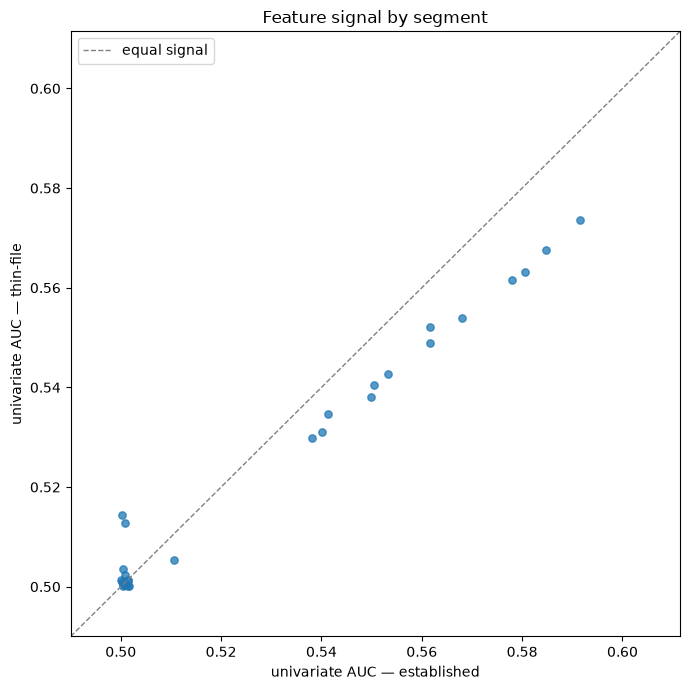

In [9]:
plot_df = compare.dropna(subset=["auc_thin", "auc_est"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_df["auc_est"], plot_df["auc_thin"], s=28, alpha=0.75)
lims = [0.49, max(plot_df[["auc_thin", "auc_est"]].max()) + 0.02]
ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, label="equal signal")

# Label the features that diverge most between segments.
for name, row in plot_df.iterrows():
    if abs(row["auc_thin"] - row["auc_est"]) > 0.02:
        ax.annotate(name, (row["auc_est"], row["auc_thin"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.set(xlabel="univariate AUC — established", ylabel="univariate AUC — thin-file",
       title="Feature signal by segment", xlim=lims, ylim=lims)
ax.legend()
plt.tight_layout()
plt.show()

Nearly every feature sits below the diagonal: the ones carrying real signal are all
weaker for thin-file applicants. The few points above the line are features with AUC
near 0.50 in both segments, where the difference is noise rather than signal.

## 4. Segment summary statistics

In [10]:
profile_cols = [c for c in [
    "age_years", "credit_to_income", "annuity_to_income", "annuity_to_credit",
    "person_count", "person_income_sum", "person_income_max", "has_coapplicant",
    "tax_record_count", "tax_amount_mean", "tax_to_declared_income",
    "prev_app_count",
] if c in fit.columns]

summary = fit.groupby("thin_file")[profile_cols].agg(["median", "mean"]).T
summary.columns = ["established", "thin-file"]
summary["ratio"] = (summary["thin-file"] / summary["established"]).round(2)
summary.round(3)

established  thin-file  ratio
age_years              median       46.144     46.240    1.0
                       mean         46.173     46.231    1.0
credit_to_income       median        0.669      0.673    1.0
                       mean          0.836      0.837    1.0
annuity_to_income      median        0.050      0.050    1.0
                       mean          0.062      0.062    1.0
annuity_to_credit      median        0.074      0.074    1.0
                       mean          0.094      0.094    1.0
person_count           median        2.000      2.000    1.0
                       mean          1.500      1.501    1.0
person_income_sum      median    32593.000  32517.000    1.0
                       mean      35873.769  35804.715    1.0
person_income_max      median    24997.000  24926.000    1.0
                       mean      27347.115  27292.543    1.0
has_coapplicant        median        1.000      1.000    1.0
                       mean          0.500      0.501    1.0
tax_record_count       median        1.000      2.000    2.0
                       mean          1.498      1.502    1.0
tax_amount_mean        median    22772.000  22766.833    1.0
                       mean      24028.208  24016.669    1.0
tax_to_declared_income median        1.033      1.030    1.0
                       mean          1.195      1.192    1.0
prev_app_count         median        2.000      2.000    1.0
                       mean          1.997      2.000    1.0

**What to look for:** are thin-file applicants younger, asking for smaller loans relative to
income, less likely to have a co-applicant? Differences here are the human story behind the
default-rate gap, and they belong in the final report.

## 5. Save for the team

In [11]:
OUT = ROOT / "data" / "processed"

coverage.to_csv(OUT / "thin_file_feature_coverage.csv")
compare.round(4).to_csv(OUT / "thin_file_feature_auc.csv")

print(f"saved thin_file_feature_coverage.csv  ({len(coverage)} features)")
print(f"saved thin_file_feature_auc.csv       ({len(compare)} features)")
print(f"\nusable for thin-file modelling: {len(usable)} of {len(feature_cols)}")

saved thin_file_feature_coverage.csv  (51 features)
saved thin_file_feature_auc.csv       (51 features)

usable for thin-file modelling: 29 of 51


Findings

1. Almost half our features are useless for thin-file applicants.

22 of the 51 numeric features are either all-zero or all-missing for people with no
credit history. That's every cb_ and pay_ feature, plus riskassesment_940T and
numberofqueries_146L. The last one stings a bit — riskassesment_940T is the single
best predictor in notebook 04's ranking, and thin-file applicants don't have it at
all. We're left with 29 features to work with.

2. Thin-file applicants default more: 26.5% vs 16.4%.

That's 260,820 thin-file and 608,739 established applicants in weeks 0 to 79.

3. Every feature that carries real signal works worse for thin-file applicants.

Of the 29 usable features, all the meaningful ones score lower within the thin-file
segment. You can see it in the scatter plot — the points that matter all sit below
the line. A few features show a slightly positive difference, but those sit at AUC
0.50 to 0.51 in both segments, so that's noise, not an advantage. Our best thin-file
signal is tax_amount_mean at 0.574, while the pooled ranking got 0.696 from
riskassesment_940T. We just know less about these people.

4. What does work: tax records, employment length, and income.

Top signals are tax_amount_mean (0.574), days_employed_700P (0.567),
person_employed_total_mean (0.563), tax_amount_max (0.561), person_income_max
(0.554). Only about 13 of the 29 features beat 0.52, so the usable set is small.
Household features are worthless here — has_coapplicant and person_count both come
out at exactly 0.500, meaning no signal at all.

5. The two groups look exactly the same on everything except credit history.

We expected thin-file applicants to be younger or poorer. They're not:

   age                 46.14 established   vs   46.24 thin-file
   credit-to-income    0.669                    0.673
   household income    32,593                   32,517
   tax amount          22,772                   22,767
   has co-applicant    0.500                    0.501

Identical. (tax_record_count shows 1 vs 2 but that's just rounding — the actual
means are 1.498 and 1.502.)

Why this matters for our project

These are the same kind of people. Same income, same age, same ability to afford the
loan. The only difference is that we can see less about one group. So the approval
gap isn't because thin-file applicants are worse borrowers — it's because we have
less evidence about them.

That's exactly why a single threshold is unfair here, and why the fix belongs in the
decision layer (two cutoffs) rather than in the model.

One caveat

The groups being identical is a quirk of the synthetic data — whoever generated it
assigned thin-file status randomly, not based on income or age. In real life a
46-year-old with zero credit history barely exists. So this finding tells us about
our dataset, not about real borrowers, and we shouldn't claim otherwise in the final
report.

Files saved

   data/processed/thin_file_feature_coverage.csv
      which features are missing or dead, by segment

   data/processed/thin_file_feature_auc.csv
      AUC for every feature, thin-file vs established